In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Bibliotecas importadas com Sucesso!")

Bibliotecas importadas com Sucesso!


In [8]:
df = pd.read_csv("exemplo_amostra.csv")


print(f"Total de Linhas: {len(df)}")
print(f"Total de Colunas: {len(df.columns)}")

print("\nDados carregados com Sucesso!")

Total de Linhas: 20
Total de Colunas: 7

Dados carregados com Sucesso!


In [9]:
df.head()

,Data,Dia_Semana,Banda,Publico,Faturamento,Custos_Banda,Custos_Operacionais
0,2025-09-05,Sexta,Rock Covers Brasil,95,2850.0,1200.0,450.0
1,2025-09-06,Sábado,Heavy Metal SP,142,4260.0,1500.0,520.0
2,2025-09-07,Domingo,Blues & Soul,78,2340.0,1100.0,380.0
3,2025-09-12,Sexta,Indie Rock,88,2640.0,1000.0,420.0
4,2025-09-13,Sábado,Tributo Queen,165,4950.0,1800.0,580.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Data                 20 non-null     object 
 1   Dia_Semana           20 non-null     object 
 2   Banda                20 non-null     object 
 3   Publico              20 non-null     int64  
 4   Faturamento          20 non-null     float64
 5   Custos_Banda         20 non-null     float64
 6   Custos_Operacionais  20 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.2+ KB


In [11]:
df['Data'] = pd.to_datetime(df['Data'])


df['Data'].dtype

dtype('<M8[ns]')

In [12]:
df.describe()

,Data,Publico,Faturamento,Custos_Banda,Custos_Operacionais
count,20,20.000000,20.000000,20.000000,20.000000
mean,2025-09-25 21:36:00,106.850000,3205.500000,1290.000000,457.000000
min,2025-09-05 00:00:00,62.000000,1860.000000,900.000000,340.000000
25%,2025-09-13 18:00:00,82.500000,2475.000000,1087.500000,395.000000
50%,2025-09-26 12:00:00,96.000000,2880.000000,1200.000000,445.000000
75%,2025-10-06 06:00:00,139.000000,4170.000000,1525.000000,525.000000
max,2025-10-18 00:00:00,165.000000,4950.000000,1800.000000,580.000000
std,NaN,32.753104,982.593105,284.049662,77.805425


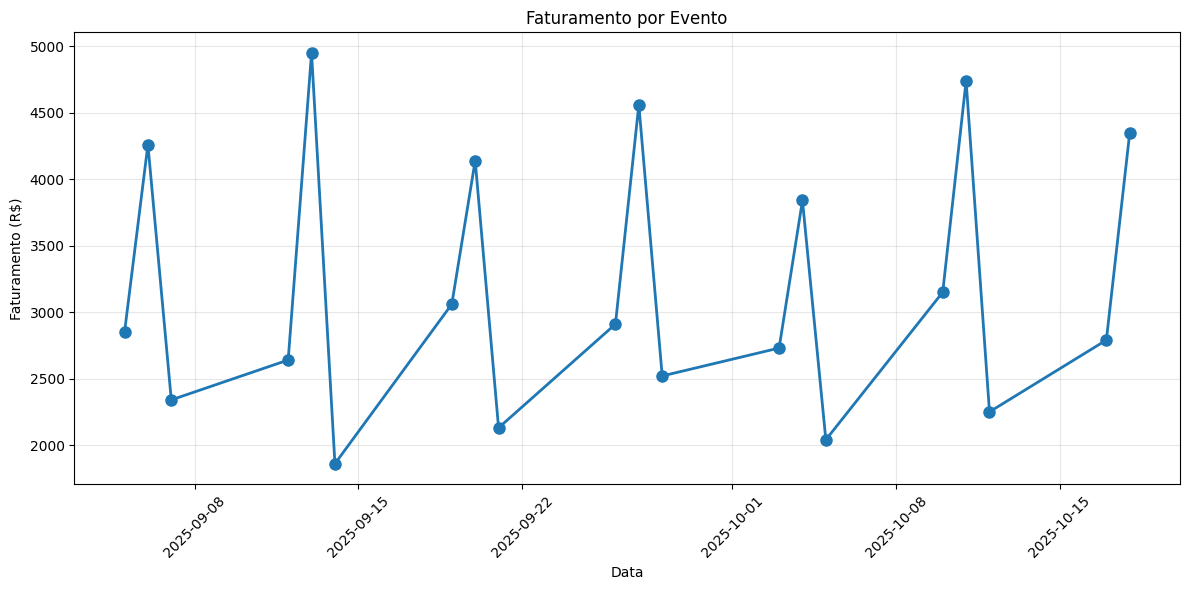

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df['Data'], df['Faturamento'], marker='o', linewidth=2, markersize=8)
plt.xlabel('Data')
plt.ylabel('Faturamento (R$)')
plt.title('Faturamento por Evento')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
faturamento_por_dia = df.groupby('Dia_Semana')['Faturamento'].mean().sort_values(ascending=False)

print(f'Faturamento por dia da semana:\n{faturamento_por_dia}')



Faturamento por dia da semana:
Dia_Semana
Sábado     4405.714286
Sexta      2875.714286
Domingo    2190.000000
Name: Faturamento, dtype: float64


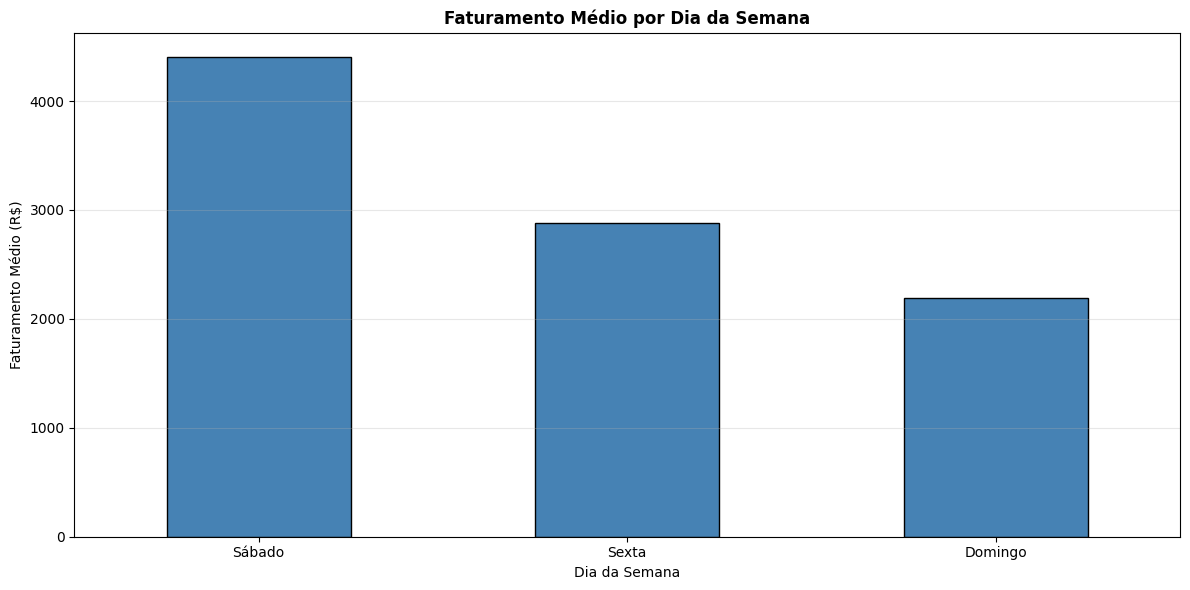

In [16]:
plt.figure(figsize=(12, 6))
faturamento_por_dia.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Dia da Semana')
plt.ylabel('Faturamento Médio (R$)')
plt.title('Faturamento Médio por Dia da Semana', fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
publico_por_dia = df.groupby('Dia_Semana')['Publico'].mean().sort_values(ascending=False)

print(f"Publico por dia da semana:\n{publico_por_dia}")

Publico por dia da semana:
Dia_Semana
Sábado     146.857143
Sexta       95.857143
Domingo     73.000000
Name: Publico, dtype: float64


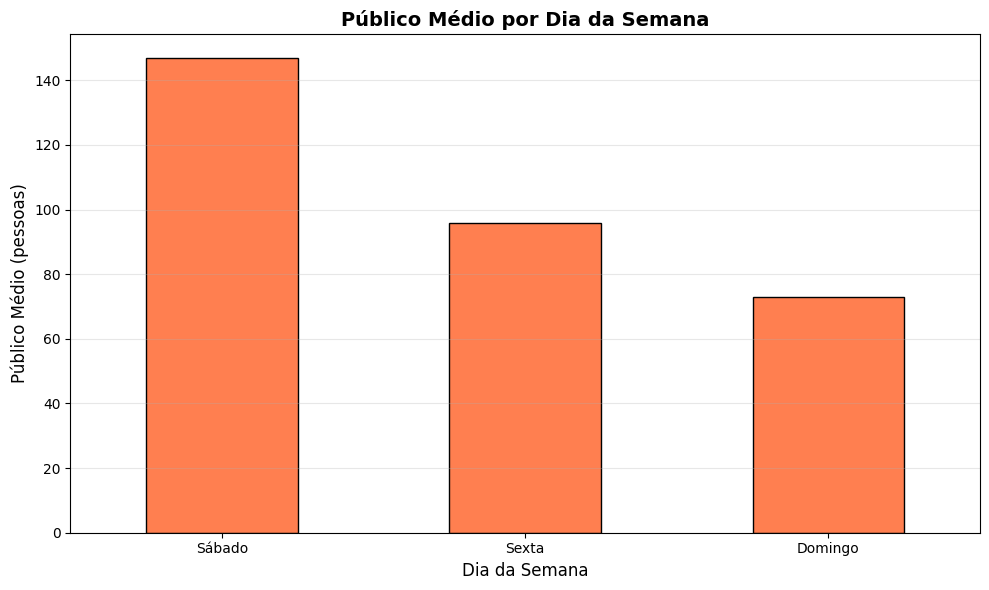

In [21]:
# Gráfico: Público médio por dia da semana
plt.figure(figsize=(10, 6))
publico_por_dia.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Público Médio (pessoas)', fontsize=12)
plt.title('Público Médio por Dia da Semana', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Top 5 bandas por público médio
top_bandas = df.groupby('Banda')['Publico'].mean().sort_values(ascending=False)

print("🎸 TOP BANDAS - PÚBLICO MÉDIO:")
print("="*50)
print(top_bandas)

🎸 TOP BANDAS - PÚBLICO MÉDIO:
Banda
Tributo Queen          165.0
Tributo Beatles        158.0
Tributo Iron Maiden    152.0
Rock Nacional          145.0
Heavy Metal SP         142.0
Classic Rock           138.0
Punk Rock SP           128.0
Grunge Revival         105.0
Pop Rock Anos 80       102.0
Hard Rock Brasil        97.0
Rock Covers Brasil      95.0
Metal Progressivo       93.0
Alternative Rock        91.0
Indie Rock              88.0
Samba Rock              84.0
Blues & Soul            78.0
Folk Nacional           75.0
Acústico MPB            71.0
Bossa Nova              68.0
Jazz Fusion             62.0
Name: Publico, dtype: float64


,Publico
Banda,
Tributo Queen,165.0
Tributo Beatles,158.0
Tributo Iron Maiden,152.0
Rock Nacional,145.0
Heavy Metal SP,142.0


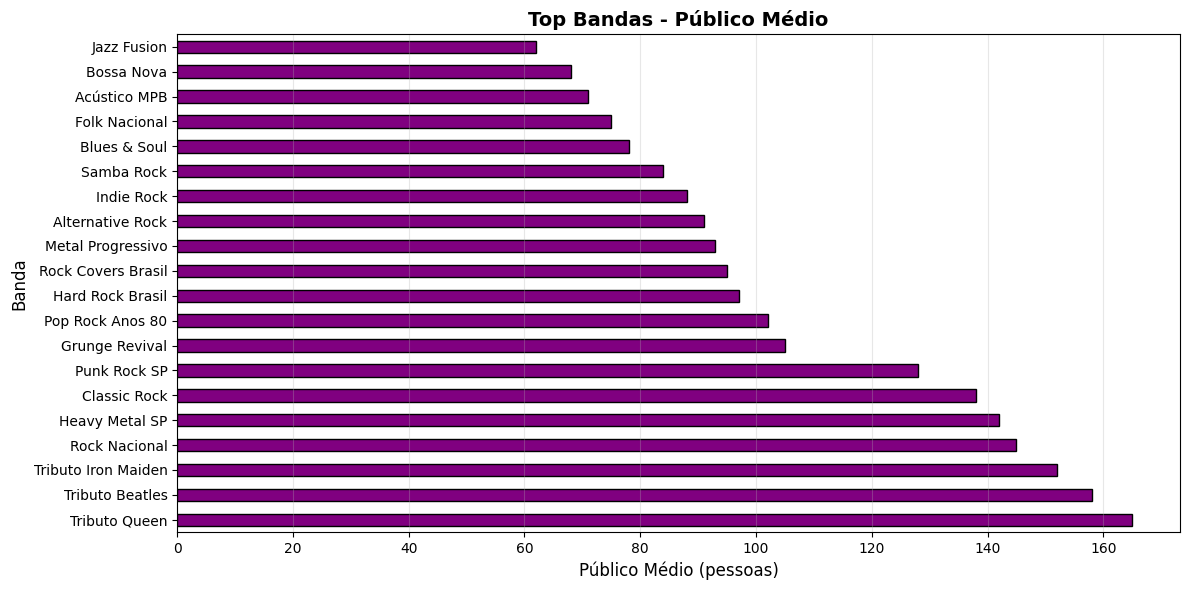

In [39]:
# Gráfico: Top Bandas por Público Médio
plt.figure(figsize=(12, 6))
top_bandas.plot(kind='barh', color='purple', edgecolor='black')
plt.xlabel('Público Médio (pessoas)', fontsize=12)
plt.ylabel('Banda', fontsize=12)
plt.title('Top Bandas - Público Médio', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
publico_faturamento = df.groupby('Faturamento')['Publico'].mean().sort_values(ascending=False)

print(f"Publico por Faturamento:\n{publico_faturamento}")


Publico por Faturamento:
Faturamento
4950.0    165.0
4740.0    158.0
4560.0    152.0
4350.0    145.0
4260.0    142.0
4140.0    138.0
3840.0    128.0
3150.0    105.0
3060.0    102.0
2910.0     97.0
2850.0     95.0
2790.0     93.0
2730.0     91.0
2640.0     88.0
2520.0     84.0
2340.0     78.0
2250.0     75.0
2130.0     71.0
2040.0     68.0
1860.0     62.0
Name: Publico, dtype: float64


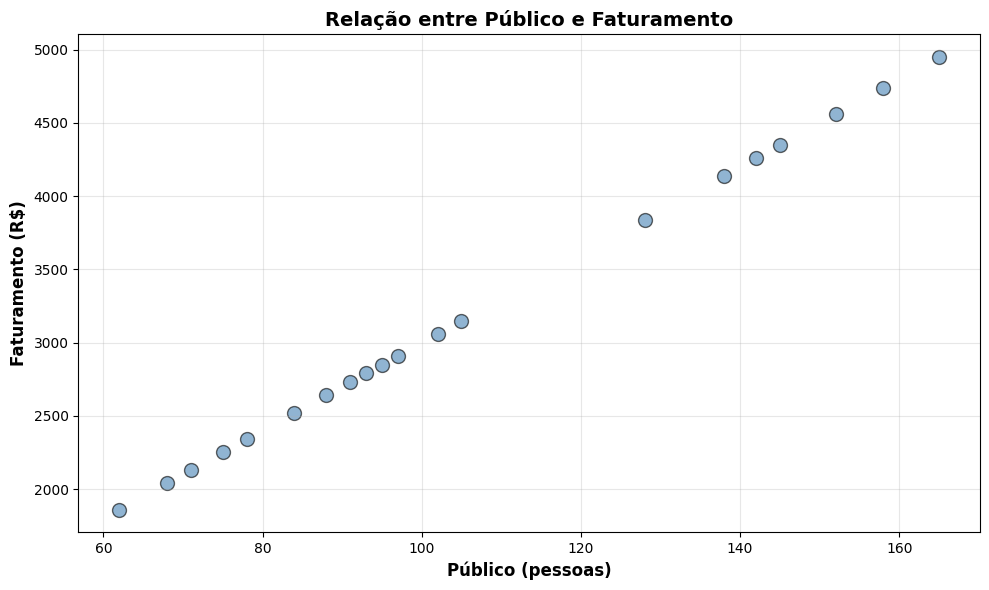

In [43]:
# Gráfico: Correlação Público x Faturamento
plt.figure(figsize=(10, 6))
plt.scatter(df['Publico'], df['Faturamento'], color='steelblue', edgecolor='black', s=100, alpha=0.6)
plt.xlabel('Público (pessoas)', fontsize=12, fontweight='bold')
plt.ylabel('Faturamento (R$)', fontsize=12, fontweight='bold')
plt.title('Relação entre Público e Faturamento', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# Calcular correlação entre Público e Faturamento
correlacao = df['Publico'].corr(df['Faturamento'])

print(f"🔗 Correlação Público x Faturamento: {correlacao:.3f}")
print("\nInterpretação:")
if correlacao > 0.8:
    print("✅ Correlação MUITO FORTE - Mais público = Mais faturamento")
elif correlacao > 0.5:
    print("✅ Correlação FORTE")
elif correlacao > 0.3:
    print("⚠️ Correlação MODERADA")
else:
    print("❌ Correlação FRACA")

🔗 Correlação Público x Faturamento: 1.000

Interpretação:
✅ Correlação MUITO FORTE - Mais público = Mais faturamento
